# 08 · Do amyloid and tau PET measures improve the prediction?

**Research question 2.** Among people who have PET, does adding the PET numbers to the clinical model improve prediction of dementia?

**Why the design is deliberately small.** The PET cohort has about 1,100 participants and under 100 events available for fitting. A flexible model with dozens of inputs would overfit. So the experiment uses **late fusion**:

1. A clinical model (XGBoost, no PET) is trained on **all** landmark visits of the training participants, whether or not they have PET. This uses the big cohort.
2. For a PET participant, that model produces one number: the clinical risk.
3. A small logistic regression combines the clinical risk with two amyloid measures (Centiloids, positive/negative) and, where available, two tau measures (meta-temporal and entorhinal SUVR, scaled within tracer). Only this last step is fitted on PET participants, and it has at most nine coefficients.

The index visit is the visit closest to the participant's first PET scan (within one year). The main horizon is **2 years**, because follow-up after PET is short; 3 years is shown as a check.

Comparisons are **paired**: the same held-out participants, scored with and without PET. Results come from `scripts/train_pet.py`.

In [1]:
import sys, json
sys.path.insert(0, "../scripts")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import nacc_utils as nu

nu.set_style()
res = json.loads((nu.REPORTS / "phase4_pet_results.json").read_text())
pd.DataFrame({t: {s: f"{v['n']:,} ({v['events']})" for s, v in res[t]["cohort"].items()} for t in res}).rename(
    columns={"y_dementia_2y": "Dementia within 2 years", "y_dementia_3y": "Dementia within 3 years"}).rename_axis("Participants (events)")

,Dementia within 2 years,Dementia within 3 years
Participants (events),,
train,911 (85),649 (110)
val,200 (11),140 (21)
test,189 (20),133 (23)
external,676 (50),482 (67)


The internal test set has only about 20 events. On its own it cannot detect anything but a very large effect. The external centres have more (about 50), and since neither set was used for fitting, the two are also shown pooled.

In [2]:
def table(target, subset):
    rows = {}
    for ev in ["test", "external", "test + external"]:
        for name, m in res[target][subset][ev].items():
            if "auroc" not in m:
                continue
            rows[(ev, name)] = {"n": m["n"], "Events": m["events"], "AUROC (95% interval)": f"{m['auroc']:.3f} ({m['auroc_ci'][0]:.3f}-{m['auroc_ci'][1]:.3f})",
                                "AUPRC": round(m["auprc"], 3),
                                "Gain in AUROC vs clinical only": "reference" if "delta_auroc" not in m else f"{m['delta_auroc']:+.4f} ({m['delta_auroc_ci'][0]:+.4f} to {m['delta_auroc_ci'][1]:+.4f})"}
    return pd.DataFrame(rows).T

print("Fitted on", res["y_dementia_2y"]["has amyloid PET"]["train_n"], "participants with", res["y_dementia_2y"]["has amyloid PET"]["train_events"], "events")
table("y_dementia_2y", "has amyloid PET")

Fitted on 1033 participants with 85 events


n Events AUROC (95% interval)  AUPRC  \
test            Clinical only       175     17  0.928 (0.881-0.967)  0.543   
                Clinical + amyloid  175     17  0.932 (0.886-0.967)  0.514   
external        Clinical only       642     47  0.961 (0.943-0.976)  0.606   
                Clinical + amyloid  642     47  0.961 (0.942-0.976)  0.604   
test + external Clinical only       817     64  0.952 (0.935-0.967)  0.575   
                Clinical + amyloid  817     64  0.952 (0.935-0.967)  0.573   

                                   Gain in AUROC vs clinical only  
test            Clinical only                           reference  
                Clinical + amyloid   +0.0037 (-0.0030 to +0.0122)  
external        Clinical only                           reference  
                Clinical + amyloid   -0.0004 (-0.0030 to +0.0022)  
test + external Clinical only                           reference  
                Clinical + amyloid   -0.0001 (-0.0024 to +0.0020)

In [3]:
print("Fitted on", res["y_dementia_2y"]["has amyloid and tau PET"]["train_n"], "participants with", res["y_dementia_2y"]["has amyloid and tau PET"]["train_events"], "events")
table("y_dementia_2y", "has amyloid and tau PET")

Fitted on 281 participants with 43 events


n Events AUROC (95% interval)  \
test            Clinical only              39      8  0.875 (0.752-0.971)   
                Clinical + amyloid         39      8  0.875 (0.752-0.971)   
                Clinical + amyloid + tau   39      8  0.883 (0.758-0.973)   
external        Clinical only             319     25  0.976 (0.957-0.990)   
                Clinical + amyloid        319     25  0.977 (0.957-0.990)   
                Clinical + amyloid + tau  319     25  0.973 (0.950-0.990)   
test + external Clinical only             358     33  0.962 (0.940-0.980)   
                Clinical + amyloid        358     33  0.963 (0.942-0.981)   
                Clinical + amyloid + tau  358     33  0.962 (0.938-0.982)   

                                          AUPRC Gain in AUROC vs clinical only  
test            Clinical only             0.641                      reference  
                Clinical + amyloid        0.641   +0.0000 (-0.0000 to +0.0000)  
                Clinical + amyloid + tau  0.714   +0.0081 (-0.0000 to +0.0429)  
external        Clinical only             0.792                      reference  
                Clinical + amyloid        0.802   +0.0011 (-0.0013 to +0.0037)  
                Clinical + amyloid + tau  0.772   -0.0029 (-0.0139 to +0.0089)  
test + external Clinical only             0.742                      reference  
                Clinical + amyloid        0.754   +0.0007 (-0.0020 to +0.0035)  
                Clinical + amyloid + tau  0.748   +0.0000 (-0.0115 to +0.0106)

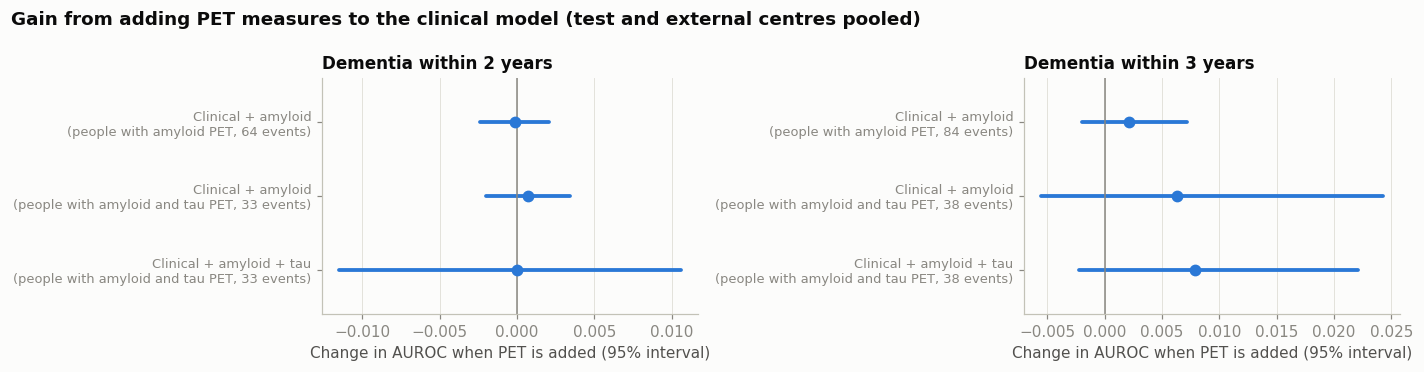

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.4))
for ax, target, title in zip(axes, ["y_dementia_2y", "y_dementia_3y"], ["Dementia within 2 years", "Dementia within 3 years"]):
    items = []
    for subset, names in [("has amyloid PET", ["Clinical + amyloid"]), ("has amyloid and tau PET", ["Clinical + amyloid", "Clinical + amyloid + tau"])]:
        for name in names:
            m = res[target][subset]["test + external"][name]
            items.append((f"{name}\n({subset.replace('has ', 'people with ')}, {m['events']} events)", m))
    for i, (lab, m) in enumerate(items[::-1]):
        ax.plot(m["delta_auroc_ci"], [i, i], color=nu.BLUE, lw=2.5, solid_capstyle="round"); ax.scatter([m["delta_auroc"]], [i], color=nu.BLUE, s=45, zorder=3)
    ax.axvline(0, color=nu.MUTED, lw=1); ax.set_yticks(range(len(items)), [l for l, _ in items[::-1]], fontsize=8.5); ax.set_ylim(-0.6, len(items) - 0.4)
    ax.set_xlabel("Change in AUROC when PET is added (95% interval)"); ax.set_title(title); ax.grid(axis="y", visible=False)
fig.suptitle("Gain from adding PET measures to the clinical model (test and external centres pooled)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); nu.savefig(fig, "08_pet_gain"); plt.show()

## Result

**Adding PET measures did not measurably improve the prediction.** Every interval for the gain includes zero, for amyloid alone and for amyloid plus tau, at 2 and at 3 years, on the internal test set, the external centres, and both pooled. The point estimates are all within about ±0.01 AUROC of zero in the larger groups.

## But amyloid status clearly matters on its own

In [5]:
rows = {}
for target, label in [("y_dementia_2y", "2 years"), ("y_dementia_3y", "3 years")]:
    for dx, d in res[target]["conversion_rate_by_amyloid_status"].items():
        for status, v in d.items():
            rows[(label, dx, f"Amyloid {status}")] = {"Participants": v["n"], "Converted": int(v["events"]), "Rate %": round(v["events"] / v["n"] * 100, 1)}
rates = pd.DataFrame(rows).T
rates

Participants  Converted  Rate %
2 years normal at index Amyloid negative         363.0        1.0     0.3
                        Amyloid positive         170.0        0.0     0.0
        MCI at index    Amyloid negative          86.0        6.0     7.0
                        Amyloid positive         154.0       52.0    33.8
3 years normal at index Amyloid negative         263.0        1.0     0.4
                        Amyloid positive         122.0        1.0     0.8
        MCI at index    Amyloid negative          53.0       12.0    22.6
                        Amyloid positive         122.0       64.0    52.5

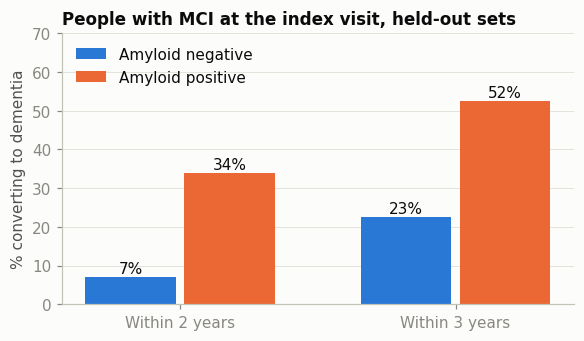

In [6]:
sub = rates.xs("MCI at index", level=1)
fig, ax = plt.subplots(figsize=(6, 3.2))
x = np.arange(2); w = 0.36
for i, (status, color) in enumerate([("Amyloid negative", nu.BLUE), ("Amyloid positive", nu.ORANGE)]):
    vals = [sub.loc[(h, status), "Rate %"] for h in ["2 years", "3 years"]]
    ax.bar(x + (i - 0.5) * w, vals, width=w - 0.03, color=color, label=status)
    for xi, v in zip(x, vals): ax.text(xi + (i - 0.5) * w, v + 1, f"{v:.0f}%", ha="center")
ax.set_xticks(x, ["Within 2 years", "Within 3 years"]); ax.set_ylabel("% converting to dementia"); ax.grid(axis="x", visible=False)
ax.set_title("People with MCI at the index visit, held-out sets"); ax.legend(loc="upper left"); ax.set_ylim(0, 70)
nu.savefig(fig, "08_conversion_by_amyloid"); plt.show()

Among people with MCI, those who are amyloid positive convert to dementia far more often than those who are amyloid negative (roughly 34% against 7% within 2 years in the held-out sets). Among cognitively normal people almost nobody converts within 2 to 3 years whatever their amyloid status, so there is nothing to predict in that window.

## How can both be true?

Amyloid status is a strong risk marker **when it is the only thing you know**. But the clinical model already knows the person's memory score, CDR-SB and age. In people with MCI, a poor memory score and a higher CDR-SB go together with being amyloid positive, so much of what amyloid would tell the model, it has already inferred from cognition. What PET adds on top is then too small to detect with this many events.

In [7]:
rows = {}
for target, label in [("y_dementia_2y", "2 years"), ("y_dementia_3y", "3 years")]:
    block = res[target]["has amyloid PET"]["test + external"].get("MCI at index", {})
    for name, m in block.items():
        rows[(label, name)] = {"n": m["n"], "Events": m["events"], "AUROC (95% interval)": f"{m['auroc']:.3f} ({m['auroc_ci'][0]:.3f}-{m['auroc_ci'][1]:.3f})",
                               "Gain vs clinical only": "reference" if "delta_auroc" not in m else f"{m['delta_auroc']:+.4f} ({m['delta_auroc_ci'][0]:+.4f} to {m['delta_auroc_ci'][1]:+.4f})"}
print("Within people who had MCI at the index visit (test and external pooled):")
pd.DataFrame(rows).T

Within people who had MCI at the index visit (test and external pooled):


n Events AUROC (95% interval)  \
2 years Clinical only       245     61  0.833 (0.771-0.886)   
        Clinical + amyloid  245     61  0.833 (0.771-0.886)   
3 years Clinical only       179     80  0.861 (0.806-0.911)   
        Clinical + amyloid  179     80  0.860 (0.801-0.910)   

                                   Gain vs clinical only  
2 years Clinical only                          reference  
        Clinical + amyloid  -0.0006 (-0.0096 to +0.0092)  
3 years Clinical only                          reference  
        Clinical + amyloid  -0.0001 (-0.0145 to +0.0174)

Even restricted to people with MCI, where amyloid status separates converters so clearly on its own, adding it to the clinical model changes AUROC by less than 0.001.

## What can and cannot be claimed

**Can be claimed**

* In this cohort, over 2 to 3 years, amyloid and tau PET summary measures did not improve discrimination beyond a clinical model that includes cognitive tests and CDR-SB.
* Amyloid positivity on its own is strongly associated with conversion among people with MCI, in line with the literature.

**Cannot be claimed**

* "PET is not useful." The intervals are wide enough to hide a modest real gain, especially for tau (about 30 events). The correct wording is "no gain was detected", with the interval.
* Anything about cognitively normal people. PET is expected to matter most there, years before symptoms, but with one or two conversions in the held-out sets this dataset cannot test it. That needs longer follow-up after the scan than exists yet.
* Anything about longer horizons. Amyloid changes precede dementia by a decade or more; a 2 to 3 year window favours measures of current function.

**Consequence for the system.** PET stays in the design as an **optional** input. The late-fusion structure used here is exactly what the interface needs: a person without PET gets the clinical risk; a person with PET gets the fused estimate. The report should state that, on current evidence, the two are close.